# FinMark Corporation – Machine Learning Solution Project
## Team 2 : Obinguar Armielyn & Penaflor Christian

## Introduction

As FinMark Corporation’s data analyst, the goal is to design a **machine learning solution** that helps address challenges in data analysis and insight generation. This project will be completed over a **12-week timeline** and will be delivered in three major phases:

- **Milestone 1: Exploratory Data Analysis (EDA)**  
  Conduct a thorough exploration of the collected datasets to understand their structure, highlight key patterns, detect anomalies, and assess overall data quality.  

- **Milestone 2: Data Visualization**  
  Create insightful visualizations that uncover relationships between variables, highlight emerging trends, and support deeper understanding of customer behavior and market dynamics.  

- **Terminal Assessment: Machine Learning Solution Presentation**  
  Develop and deliver a comprehensive presentation documenting the process, insights, and proposed machine learning solution. This will include the approach to EDA, visualization outcomes, challenges encountered, and key findings.  

---

## Available Datasets

The following datasets are provided for this project and will be used consistently across all milestones:

1. **Customer Segments** – demographic details of FinMark’s customers.  
2. **Customer Transactions** – purchase history and transaction-level details.  
3. **Social Media Interactions** – customer engagement and sentiment data from online platforms.  

These datasets form the foundation of the analysis, visual exploration, and eventual machine learning modeling.


## Import Libraries

In [1]:
import os
import math
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inline plotting
%matplotlib inline

# Display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

In [2]:
# Set global style
sns.set_theme(style="whitegrid")


custom_palette = sns.color_palette("crest", as_cmap=False)
sns.set_palette(custom_palette)

In [3]:
df = pd.read_csv("final_merged_dataset.csv")

TARGET = None
MAX_NUMERIC_PLOTS = 20
TOP_CATS = 10

print("Data loaded successfully!")
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

Data loaded successfully!
Shape: (2667, 17)


,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod,IsHighSpender,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
0,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,504a03b0-294d-4e3c-9bf7-46935ba6c47a,2023-01-22,496.625,Clothing,Debit Card,0,0626cfe9-8e7f-4b19-ba9b-21330cd007c8,2024-01-11,Instagram,Comment,Negative
1,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,504a03b0-294d-4e3c-9bf7-46935ba6c47a,2023-01-22,496.625,Clothing,Debit Card,0,20320eb9-5f38-41f5-b855-e0a0880d8c46,2023-08-25,Facebook,Share,Positive
2,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,d4922534-dfd9-47d9-8fc8-d0421284b682,2022-09-14,660.870,Home & Garden,Bank Transfer,0,0626cfe9-8e7f-4b19-ba9b-21330cd007c8,2024-01-11,Instagram,Comment,Negative
3,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17,d4922534-dfd9-47d9-8fc8-d0421284b682,2022-09-14,660.870,Home & Garden,Bank Transfer,0,20320eb9-5f38-41f5-b855-e0a0880d8c46,2023-08-25,Facebook,Share,Positive
4,5fb09cd8-a473-46f7-80bd-6e49cf509078,45.0,Female,Castilloport,High,2020-07-21,99917043-698e-4753-a1fb-61b4afdd4da3,2022-11-11,976.880,Electronics,Paypal,0,3d962e49-3930-4131-aa8f-ad8753338770,2024-01-01,Instagram,Share,Positive


,dtype
CustomerID,object
Age,float64
Gender,object
Location,object
IncomeLevel,object
SignupDate,object
TransactionID,object
TransactionDate,object
Amount,float64
ProductCategory,object


In [4]:
for col in ["SignupDate", "TransactionDate", "InteractionDate"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [5]:
# Numeric expectations
for col in ["Age", "Amount", "IsHighSpender"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

## Customer Demographics - Visualization

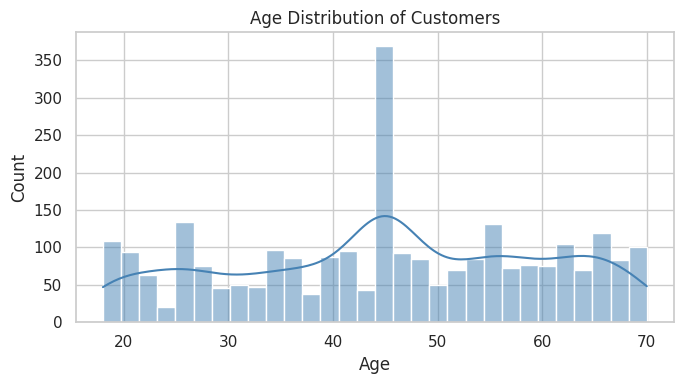

In [6]:
# Age distribution
if "Age" in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
    plt.title("Age Distribution of Customers")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

####

- Technical: The age histogram reveals the central tendency and skew (e.g., concentration in mid-20s to mid-30s and any tail toward older cohorts). A pronounced peak with a right/left tail suggests non-normality, which matters for parametric models and scaling.
- Business: If the mass is Gen Z/Millennial, prioritize mobile-first UX, social channels, and bundles aligned to this cohort’s spending behavior. Sparse older segments imply targeted campaigns (senior discounts or category curation) rather than broad spend.

## Transaction & Spending Behavior - Visualization

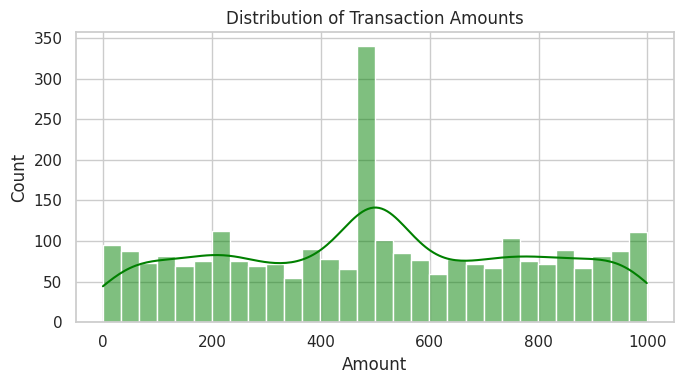

In [7]:
# spending behavior
if "Amount" in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df["Amount"], bins=30, kde=True, color="green")
    plt.title("Distribution of Transaction Amounts")
    plt.xlabel("Amount")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

####
- Technical: Heavy right tails/outliers suggest considering robust scalers or log transforms before correlation/regression.
- Business: A long tail indicates whale customers; design VIP perks and retention flows to protect LTV.

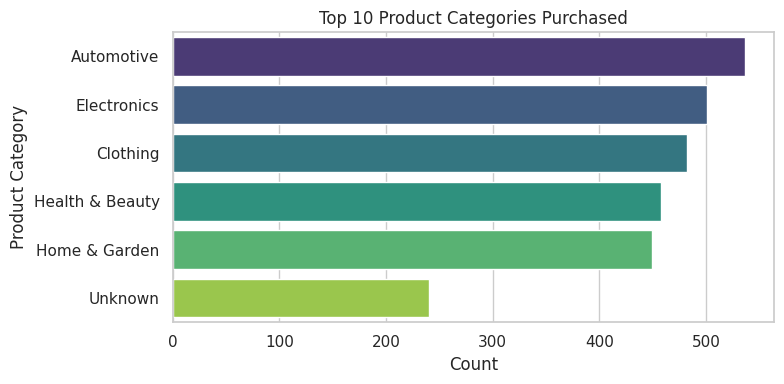

In [8]:
if "ProductCategory" in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(
        data=df,
        y="ProductCategory",
        order=df["ProductCategory"].value_counts().head(10).index,
        palette="viridis"
    )
    plt.title("Top 10 Product Categories Purchased")
    plt.ylabel("Product Category")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

####

- Technical: Category frequency highlights class imbalance; rare classes may need grouping to stabilize estimates.
- Business: Lean into top categories for hero SKUs and optimize inventory; low-volume categories may be upsell accessories or candidates for pruning.

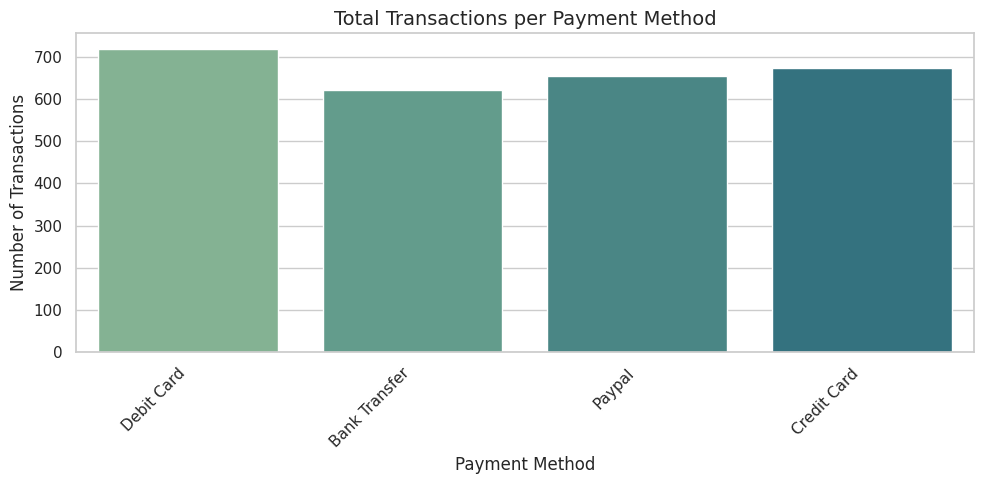

In [9]:
if "PaymentMethod" in df.columns:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(
        data=df,
        x="PaymentMethod",
        palette=custom_palette
    )
    ax.set_title("Total Transactions per Payment Method", fontsize=14)
    ax.set_xlabel("Payment Method")
    ax.set_ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


####

- Technical: Visible separation across hues suggests interaction effects; test with logistic regression or tree models including the interaction term.
- Business: If high spenders skew to specific methods (e.g., card/BNPL), negotiate fees, optimize checkout UX, and feature those methods prominently.

## Time Series Trends - Visualization

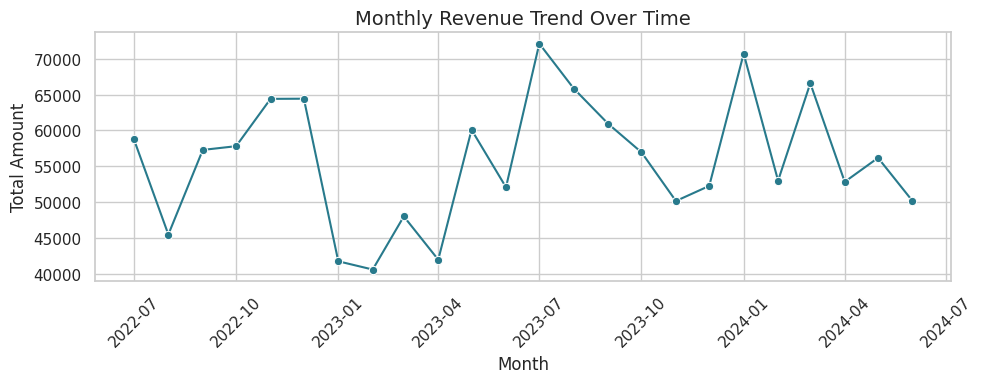

In [10]:
if "TransactionDate" in df.columns and "Amount" in df.columns:
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")

    # Drop rows without a valid date
    monthly_df = df.dropna(subset=["TransactionDate"]).copy()

    # Extract monthly period safely
    monthly_df["Month"] = monthly_df["TransactionDate"].dt.to_period("M").dt.to_timestamp()

    # Group by month
    monthly = monthly_df.groupby("Month", as_index=False)["Amount"].sum()

    if not monthly.empty:
        plt.figure(figsize=(10, 4))
        sns.lineplot(data=monthly, x="Month", y="Amount", marker="o", color=custom_palette[3])
        plt.title("Monthly Revenue Trend Over Time", fontsize=14)
        plt.xlabel("Month")
        plt.ylabel("Total Amount")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid transaction dates to plot.")


####
- Technical: Trend/seasonality suggest adding calendar dummies or STL decomposition for forecasting.
- Business: Peaks align with campaigns or paydays; replicate successful timing and smooth troughs with promos.

## Engagement & Interactions - Visualization

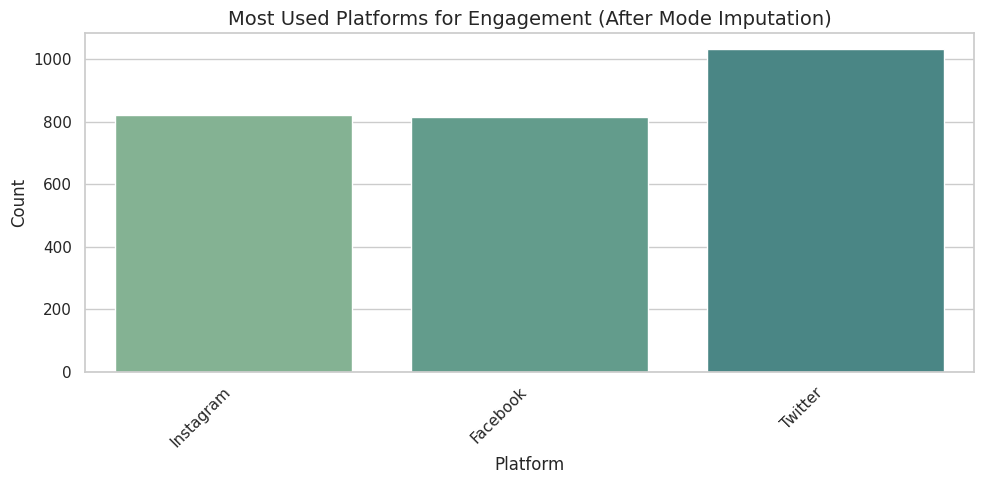

All 'Unknown' values in Platform were imputed with mode: Twitter


In [11]:
# Perform mode imputation for 'Platform' before visualization
if "Platform" in df.columns:
    # Replace 'Unknown' (any case) with NaN
    df["Platform"] = df["Platform"].replace(
        to_replace=r"(?i)^unknown$",
        value=np.nan,
        regex=True
    )

    # Fill missing values with the mode (most frequent platform)
    mode_platform = df["Platform"].mode()[0]
    df["Platform"].fillna(mode_platform, inplace=True)

    # Visualization after imputation
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(
        data=df,
        x="Platform",
        hue="Platform",
        dodge=False,
        palette=custom_palette
    )
    ax.set_title("Most Used Platforms for Engagement (After Mode Imputation)", fontsize=14)
    ax.set_xlabel("Platform")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.legend([], [], frameon=False)
    plt.tight_layout()
    plt.show()

    print(f"All 'Unknown' values in Platform were imputed with mode: {mode_platform}")


####

- Technical: Strong dominance indicates channel concentration risk; consider adding entropy metrics of platform usage.
- Business: Double down on dominant platforms for paid/organic; test new formats on runner-ups to diversify reach.

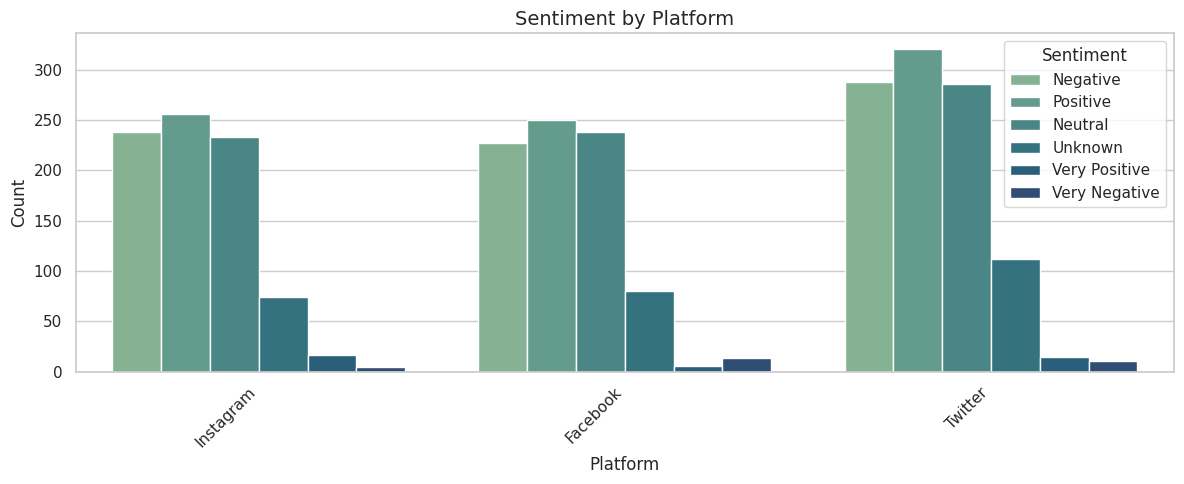

In [17]:
if "Platform" in df.columns and "Sentiment" in df.columns:
    plt.figure(figsize=(12, 5))
    ax = sns.countplot(data=df, x="Platform", hue="Sentiment")
    ax.set_title("Sentiment by Platform", fontsize=14)
    ax.set_xlabel("Platform"); ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

####

- Technical: Significant cross-platform sentiment differences imply interaction effects; check with chi-square tests.
- Business: Platforms with higher negative sentiment need CX fixes or content style changes; positive platforms are ideal for launches and testimonials.

## Correlations & Relationships - Visualization

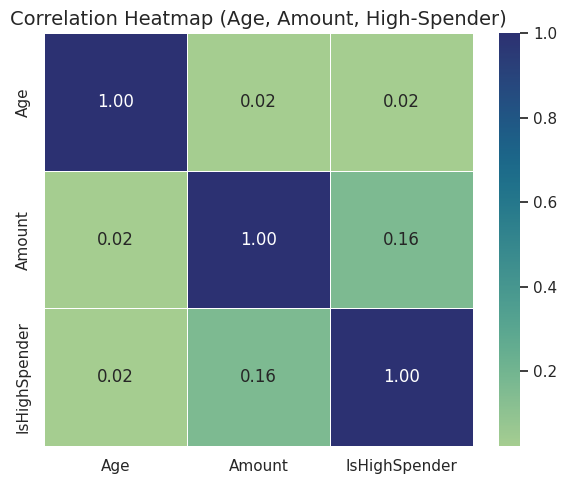

In [ ]:
num_cols = [c for c in ["Age", "Amount", "IsHighSpender"] if c in df.columns]
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        corr,
        annot=True,
        cmap="crest",
        fmt=".2f",
        linewidths=0.5
    )
    ax.set_title("Correlation Heatmap (Age, Amount, High-Spender)", fontsize=14)
    plt.tight_layout()
    plt.show()


####

- Technical: Note strong ± correlations for feature selection; watch multicollinearity (VIF) before linear models.
- Business: Highly correlated drivers can inform bundled offers (e.g., attributes that move together in high-value baskets).

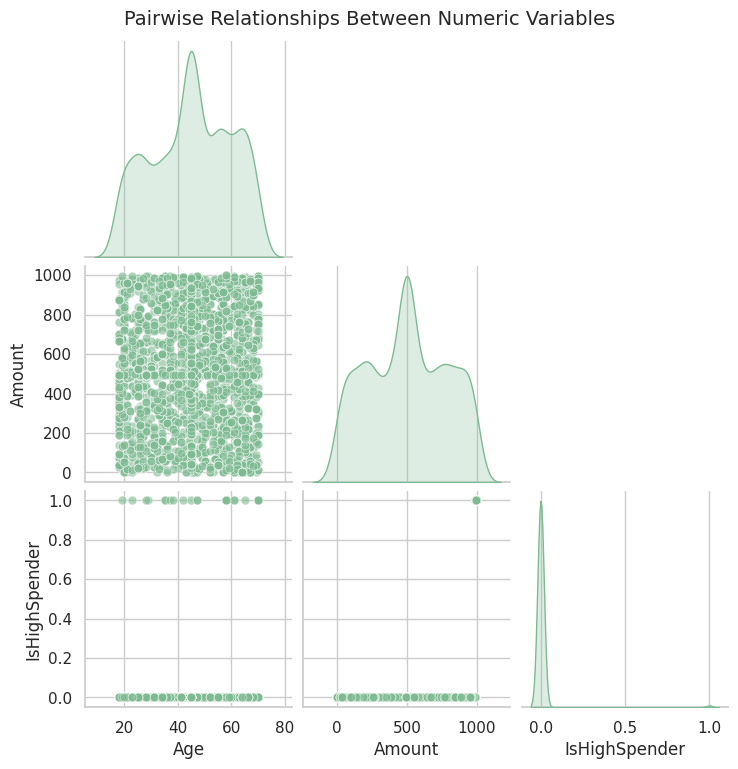

In [ ]:
#Pairwise Pearson Relationships
sns.pairplot(
    df,
    diag_kind="kde",
    corner=True,
    plot_kws={'alpha': 0.6, 's': 40}
)
plt.suptitle("Pairwise Relationships Between Numeric Variables", y=1.02, fontsize=14)
plt.show()


####

- Technical: Diagonal KDEs show marginal shapes; off-diagonal scatter reveals non-linear structures missed by Pearson.
- Business: Visible clusters suggest segmentable behaviors (e.g., price-sensitive vs premium-leaning).

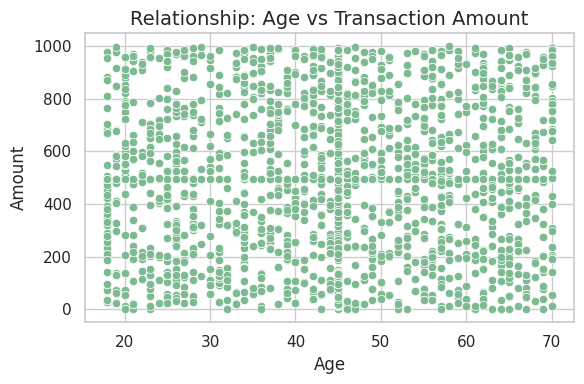

In [ ]:
if "Age" in df.columns and "Amount" in df.columns:
    plt.figure(figsize=(6, 4))
    ax = sns.scatterplot(data=df, x="Age", y="Amount")
    ax.set_title("Relationship: Age vs Transaction Amount", fontsize=14)
    ax.set_xlabel("Age"); ax.set_ylabel("Amount")
    plt.tight_layout(); plt.show()

####


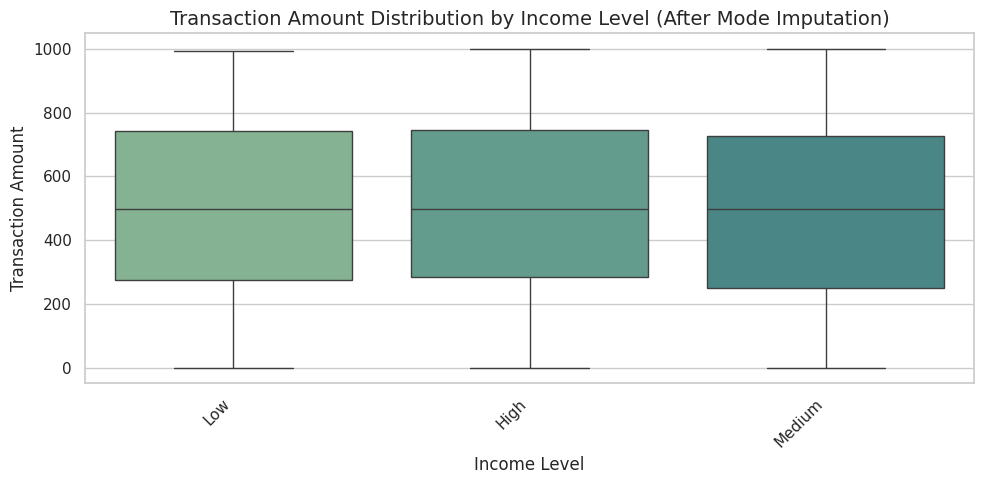

All 'Unknown' or missing IncomeLevel values imputed with mode: High


In [ ]:
# Perform mode imputation for 'IncomeLevel' before visualization
if "IncomeLevel" in df.columns and "Amount" in df.columns:
    # Replace 'Unknown' (case-insensitive) with NaN
    df["IncomeLevel"] = df["IncomeLevel"].replace(
        to_replace=r"(?i)^unknown$",
        value=np.nan,
        regex=True
    )

    # Fill NaN with the most frequent (mode) income level
    mode_income = df["IncomeLevel"].mode()[0]
    df["IncomeLevel"].fillna(mode_income, inplace=True)

    # Visualization: Transaction Amount by Income Level
    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(
        data=df,
        x="IncomeLevel",
        y="Amount",
        palette=custom_palette
    )
    ax.set_title("Transaction Amount Distribution by Income Level (After Mode Imputation)", fontsize=14)
    ax.set_xlabel("Income Level")
    ax.set_ylabel("Transaction Amount")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(f"All 'Unknown' or missing IncomeLevel values imputed with mode: {mode_income}")



####

- Technical: Separation between hues indicates conditional dependence; consider interaction terms or tree models that capture splits by spender status.
- Business: If high spend clusters at certain ages, tailor VIP offers and lifecycle emails to those cohorts.

## High-spender Insights - Visualization

In [ ]:
if "IncomeLevel" in df.columns:
    # Replace string 'Unknown' (case-insensitive) with NaN
    df["IncomeLevel"] = df["IncomeLevel"].replace(
        to_replace=r"(?i)^unknown$",
        value=np.nan,
        regex=True
    )

    # Compute mode (most frequent valid category)
    mode_income = df["IncomeLevel"].mode()[0]

    # Fill missing/unknown with mode
    df["IncomeLevel"].fillna(mode_income, inplace=True)

    print(f"Filled missing or 'Unknown' IncomeLevel values with mode: {mode_income}")


Filled missing or 'Unknown' IncomeLevel values with mode: High


In [ ]:
print(df["IncomeLevel"].value_counts())


IncomeLevel
High      1126
Low        792
Medium     749
Name: count, dtype: int64


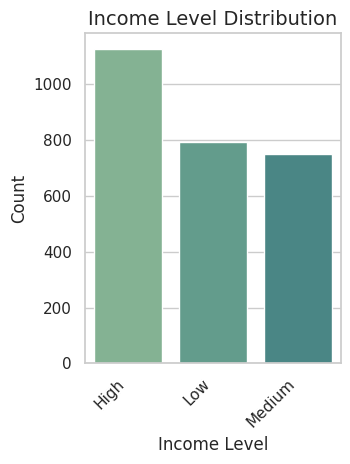

In [ ]:
plt.subplot(1, 2, 2)
sns.countplot(
    data=df,
    x="IncomeLevel",
    order=df["IncomeLevel"].value_counts().index,
    palette=custom_palette
)
plt.title("Income Level Distribution", fontsize=14)
plt.xlabel("Income Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

####

- Technical: Clear monotonic lift across income bands supports using Income as a strong predictor; check partial dependence.
- Business: Prioritize premium bundles and financing options in higher tiers; provide value packs for lower tiers.

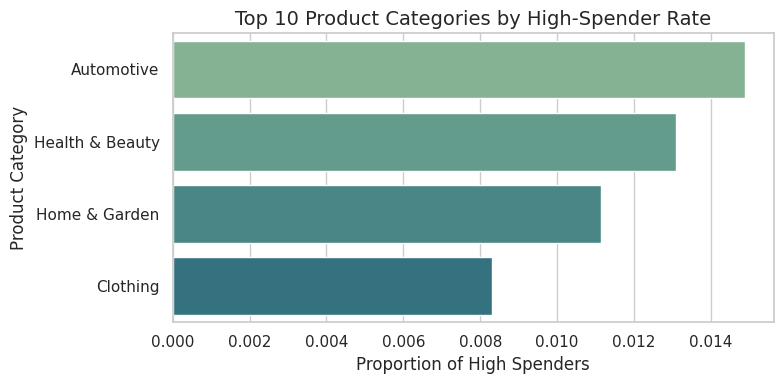

In [ ]:
if "ProductCategory" in df.columns and "IsHighSpender" in df.columns:

    df_filtered = df[
        df["ProductCategory"].notna() &
        (df["ProductCategory"].str.lower() != "unknown")
    ]


    prop_cat = (
        df_filtered.groupby("ProductCategory")["IsHighSpender"]
        .mean()
        .reset_index()
    )


    prop_cat = prop_cat[prop_cat["IsHighSpender"] > 0]


    prop_cat = prop_cat.sort_values("IsHighSpender", ascending=False).head(10)

    # 5. Visualization
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(
        data=prop_cat,
        y="ProductCategory",
        x="IsHighSpender",
        palette=custom_palette
    )
    ax.set_title("Top 10 Product Categories by High-Spender Rate", fontsize=14)
    ax.set_xlabel("Proportion of High Spenders")
    ax.set_ylabel("Product Category")
    plt.tight_layout()
    plt.show()



####

- Technical: Rate stability matters; large variance suggests low event counts—use Wilson intervals or Beta-Binomial smoothing.
- Business: Rising rate indicates successful premium conversion; align CRM pushes with months showing lift.

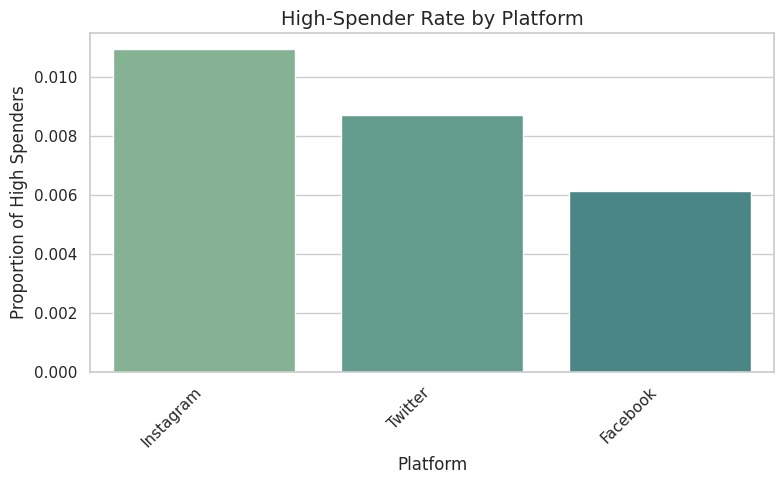

Missing or 'Unknown' Platform values were imputed with mode: Twitter


In [ ]:
if "Platform" in df.columns and "IsHighSpender" in df.columns:

    df["Platform"] = df["Platform"].replace(
        to_replace=r"(?i)^unknown$",
        value=np.nan,
        regex=True
    )


    mode_platform = df["Platform"].mode()[0]
    df["Platform"].fillna(mode_platform, inplace=True)


    prop_platform = (
        df.groupby("Platform")["IsHighSpender"]
        .mean()
        .reset_index()
        .sort_values("IsHighSpender", ascending=False)
    )

    # Visualization
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=prop_platform,
        x="Platform",
        y="IsHighSpender",
        palette=custom_palette
    )
    ax.set_title("High-Spender Rate by Platform", fontsize=14)
    ax.set_xlabel("Platform")
    ax.set_ylabel("Proportion of High Spenders")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(f"Missing or 'Unknown' Platform values were imputed with mode: {mode_platform}")


####

- Technical: High variance categories may need minimum support thresholds; consider Bayesian smoothing for reliable ranking.
- Business: Feature top categories in paid placements and homepage tiles for premium growth; test cross-sell bundles from adjacent categories.

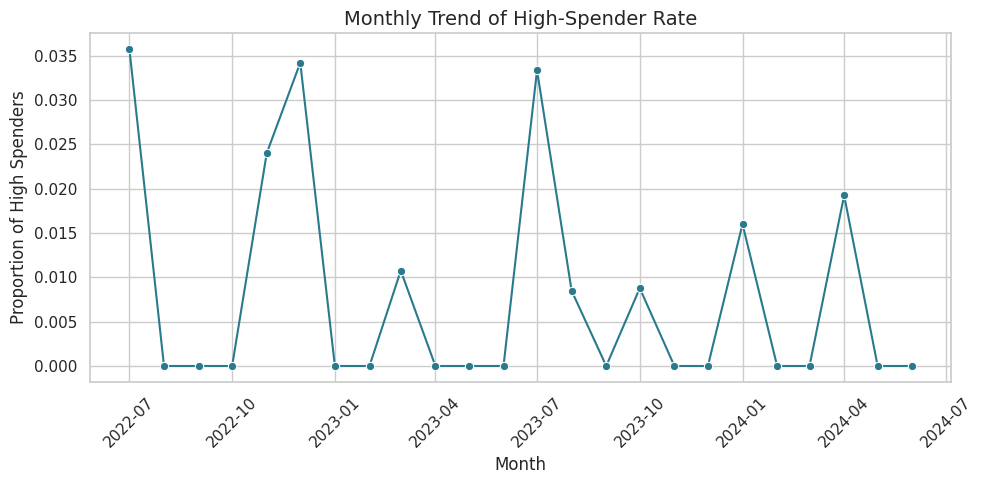

In [ ]:
if "TransactionDate" in df.columns and "IsHighSpender" in df.columns:
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
    monthly_spenders = (
        df.dropna(subset=["TransactionDate"])
        .assign(Month=df["TransactionDate"].dt.to_period("M").dt.to_timestamp())
        .groupby("Month")["IsHighSpender"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    ax = sns.lineplot(
        data=monthly_spenders,
        x="Month",
        y="IsHighSpender",
        marker="o",
        color=custom_palette[3]
    )
    ax.set_title("Monthly Trend of High-Spender Rate", fontsize=14)
    ax.set_xlabel("Month")
    ax.set_ylabel("Proportion of High Spenders")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


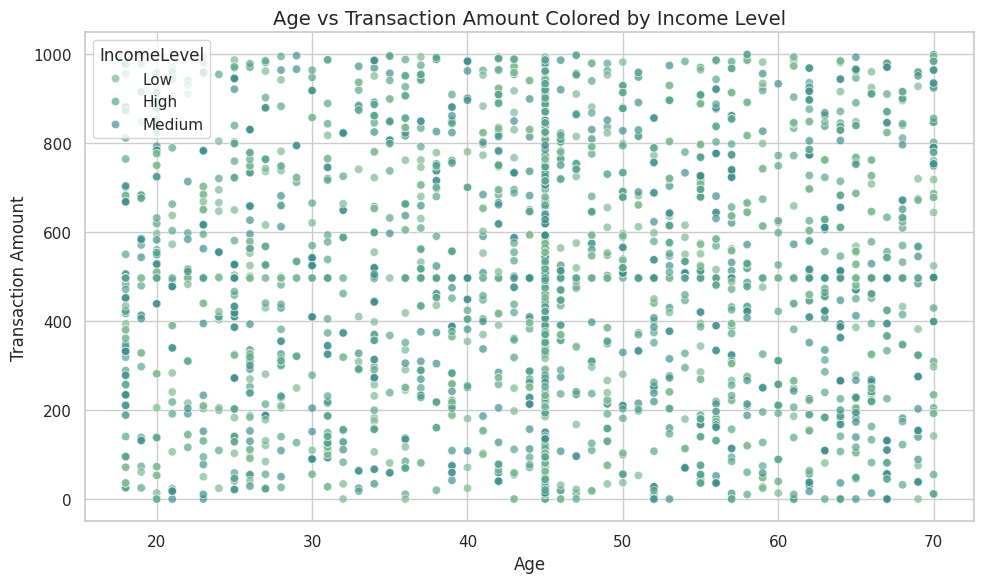

In [ ]:
if "Age" in df.columns and "Amount" in df.columns and "IncomeLevel" in df.columns:
    plt.figure(figsize=(10, 6))
    ax = sns.scatterplot(
        data=df,
        x="Age",
        y="Amount",
        hue="IncomeLevel",
        palette=custom_palette,
        alpha=0.7
    )
    ax.set_title("Age vs Transaction Amount Colored by Income Level", fontsize=14)
    ax.set_xlabel("Age")
    ax.set_ylabel("Transaction Amount")
    plt.tight_layout()
    plt.show()


####

- Technical: Platform effect can be causal (audience mix) or confounded (campaign/creative differences); validate with controlled experiments.
- Business: Scale budgets toward platforms with higher premium yield; tune creatives and landing flows on underperformers.

# Analysis

1. Demographics & Segmentation

The age distribution peaks between 40–45 years old, identifying mid-career professionals as the platform’s dominant demographic segment. Younger (18–25) and older (50+) users represent smaller portions of the user base, indicating potential areas for targeted growth.
From a business perspective, this mid-aged demographic suggests a focus on reliability, practicality, and value-driven experiences rather than purely trend-based marketing. Pricing, loyalty programs, and communication tone should be aligned with this segment’s higher purchasing power and preference for stable digital services.

2. Transaction Behavior & Spending Patterns

Transaction behavior is right-skewed, with most users spending moderately (₱400–₱600) and a small cluster of high-value transactions (₱900–₱1000) contributing a significant share of revenue.
This concentration indicates both revenue dependency on top spenders and an opportunity to nurture consistent mid-range buyers through loyalty programs or bundle offers.
Both high- and low-income users show active spending patterns, while middle-income users record the lowest spend levels — suggesting income doesn’t directly predict frequency, but rather spending style. These insights can guide differentiated marketing strategies: premium engagement for high-income users and rewards for loyal low-income segments.

3. Product Category Trends

Automotive ranks as the top-purchased category, followed by Electronics, Clothing, and Health & Beauty, with Unknown trailing last.
This reveals strong demand for practical and technology-oriented products, making these categories primary revenue drivers. Meanwhile, fashion and beauty items show stable but secondary engagement, suitable for seasonal or promotional campaigns.
The low volume in “Unknown” suggests either incomplete labeling or emerging niche products that could benefit from clearer classification or deeper analysis.

4. Engagement & Sentiment Dynamics

User engagement is concentrated across Twitter, Facebook, and Instagram, with Twitter leading in total interactions and sentiment activity.
Sentiment distribution across platforms is largely balanced, with positive and neutral sentiments dominating and negative sentiment appearing in smaller proportions.
This indicates a generally satisfied user base with healthy brand perception. Twitter’s high engagement and positive tone make it ideal for community building and campaign launches, while Facebook and Instagram may require content or UX improvements to deepen engagement and reduce neutral sentiment.

5. Correlations & Predictive Relationships

Correlation analysis shows weak relationships among Age, Transaction Amount, and High-Spender status (ranging only from 0.02 to 0.16).
This implies that age alone does not drive spending, and other factors (e.g., income, platform, or category) influence behavior more strongly.
Low correlations mean the dataset has little redundancy, allowing each feature to contribute unique predictive value — a good foundation for machine learning models or segmentation-based personalization.

6. High-Spender Insights

High spenders are distributed across both low- and high-income segments, showing diverse purchasing motivations — some buy frequently in smaller amounts, others occasionally in larger sums.
These users are most active in Automotive and Electronics categories, suggesting a preference for functional, high-value, or upgrade-based products.
Platforms with strong spending behavior (particularly Twitter) present opportunities for premium-tier campaigns, personalized product recommendations, and exclusive loyalty programs aimed at retaining top spenders and stimulating recurring purchases.

7. General Business Implications

- Target Segment: Mid-career, financially stable users (40–45 years old).

- Spending Pattern: Mostly mid-range with a small set of high-value contributors.

- Top Categories: Automotive and Electronics as core revenue sources.

- Platform Strategy: Focus engagement efforts on Twitter, maintain presence on Facebook and Instagram with improved personalization.

- Predictive Opportunity: Weak correlations allow for independent feature use in machine learning models for churn prediction or spending classification.